Ensure that the MCMC can recover known parameter values

In [1]:
import importlib
from escripts import eMCMC
from escripts import eplots
Plotting = eplots.Plotting()
from escripts import estats
import matplotlib.ticker as ticker

In [2]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [3]:
all_file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [4]:
my_UVLF = eMCMC.UVLF(all_file_names, data_labels)

In [5]:
true_params = [0.66, -0.07, -0.38, -0.01, 12.03, 0.17, -0.95, -0.03, 0.42, 0.04, 0]

In [6]:
mock_phiUV = []
yerr_uppers = []
yerr_lowers = []

for dataarrayz in my_UVLF.data: # Add the log likelihoods together for each redshift. The log likelihood is just a sum over all the points
    # anyways, so this makes sense
    zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = eMCMC.decompose_data(dataarrayz)
    avg_UV = my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, true_params)
    sampled_UV = np.random.normal(loc = avg_UV, scale = np.fmin(avg_UV, (yerr_upper+yerr_lower)/20))
    mock_phiUV.append(sampled_UV)
    # Maintain the same ratio between the error bars & the data
    yerr_uppers.append(sampled_UV*yerr_upper/ydat)
    yerr_lowers.append(sampled_UV*yerr_lower/ydat)  

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


In [7]:
mock_phiUV

[array([3.91788402e-06, 2.26770032e-05, 1.04757209e-04, 3.25867073e-04,
        7.63270564e-04, 1.38007449e-03, 2.49349472e-03, 3.47229060e-03,
        4.57074055e-03, 1.02228964e-02, 2.08283724e-02, 3.54465418e-02]),
 array([4.73403324e-07, 4.02714468e-06, 2.48115651e-05, 9.30502478e-05,
        2.44886077e-04, 5.03813120e-04, 9.98734964e-04, 1.56961542e-03,
        2.64419775e-03, 5.38394440e-03, 1.15003480e-02, 2.20576671e-02]),
 array([3.08212587e-06, 1.44439877e-05, 5.24918499e-05, 1.44495424e-04,
        3.30390398e-04, 6.63407076e-04, 1.18958083e-03, 2.48214297e-03,
        5.78314274e-03, 1.24078895e-02]),
 array([3.74602465e-06, 1.38537560e-05, 4.25868632e-05, 1.09329771e-04,
        2.40250665e-04, 4.66247919e-04, 9.33294873e-04, 1.40648345e-03,
        3.44487559e-03, 7.66561275e-03]),
 array([5.08410060e-06, 1.45257160e-05, 3.92399726e-05, 1.37323994e-04,
        3.87607860e-04, 9.04281792e-04, 2.29728324e-03]),
 array([1.10553460e-06, 7.61374402e-06, 3.80046143e-05, 2.6619

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_52021/2307377991.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


Text(0.5, -0.05, '$M_{\\rm{UV}}$ [mag]')

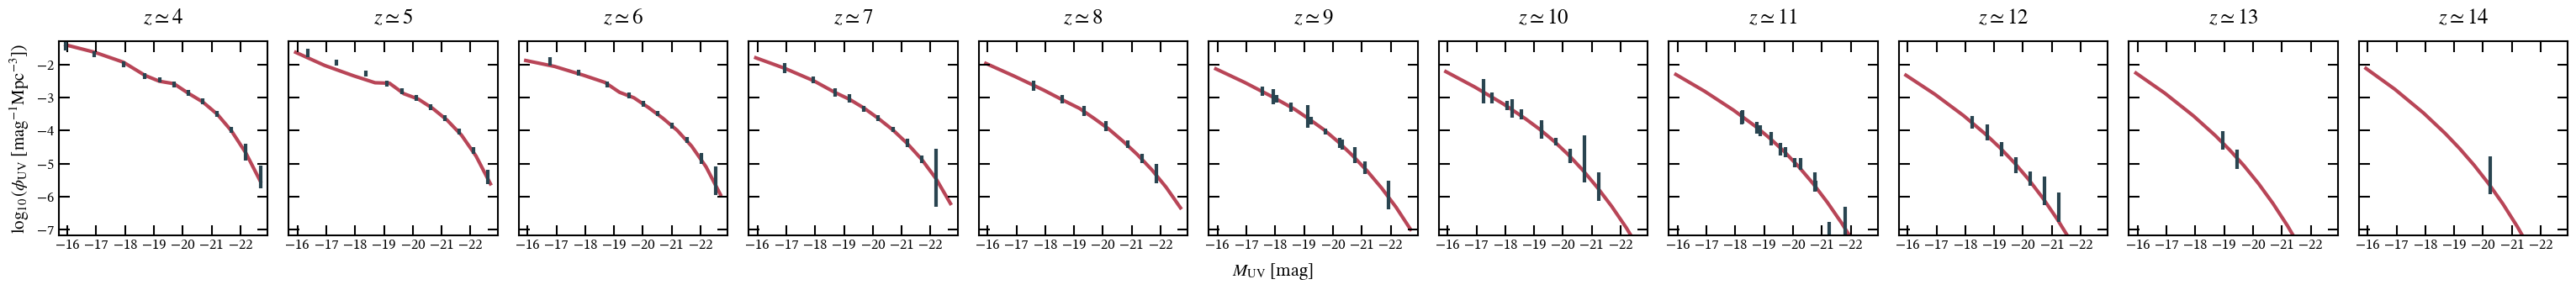

In [8]:
fig, ax = plt.subplots(1, len(mock_phiUV), sharey = True)
fig.set_size_inches(3.5*len(mock_phiUV), 3)
plt.subplots_adjust(wspace = 0.1)

# Set the same y limits for all the plots
ylo, yhi = np.log10(min([min(dat[3]) for dat in my_UVLF.data]))-0.25, np.log10(max([max(dat[3]) for dat in my_UVLF.data]))+0.25

plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5], # Use the lowest redshift MUV centers & bins to calculate the theoretical
                                                            # UVLF (this will make it the smoothest)

for i, (dataarrayz, ydat, yerr_upper, yerr_lower) in enumerate(zip(my_UVLF.data, mock_phiUV, yerr_uppers, yerr_lowers)):
    zdat, zerr, xdat, _, _, _, _ = eMCMC.decompose_data(dataarrayz)

    # Plot best fit:
    ax[i].plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,true_params)), zorder = 1, color = Plotting.red, 
               linestyle = '-')
    
    yerr_lower, yerr_upper = estats.calc_log_error(ydat, yerr_lower), estats.calc_log_error(ydat, yerr_upper)
    ax[i].errorbar(xdat, np.log10(ydat), [yerr_lower, yerr_upper], capsize=0, markersize = 9, markeredgecolor = 'none', 
                   markerfacecolor = Plotting.navy, ecolor = Plotting.navy, ls = 'none')
    
    ax[i].invert_xaxis()
    ax[i].set_ylim(ylo, yhi)
    ax[i].set_xlim(np.max(plot_xdat)+0.25, np.min(plot_xdat)-0.25)
    ax[i].set_title(f'$z \simeq {int(zdat)}$')
    ax[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                   # axis labels
ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')

In [9]:
redshifts = np.concatenate([np.full(len(dat[2]), dat[0]) for dat in my_UVLF.data])
magnitudes = np.concatenate([dat[2] for dat in my_UVLF.data])
dmag = np.concatenate([dat[6] for dat in my_UVLF.data])

In [10]:
eMCMC.save_data(redshifts, magnitudes, dmag, np.concatenate(mock_phiUV), np.concatenate(yerr_uppers), np.concatenate(yerr_lowers), 
                '/Users/eb35267/Desktop/code/home/data/mock_data_with_error.txt')

AttributeError: module 'escripts.eMCMC' has no attribute 'save_data'

In [297]:
mock_files = ['/Users/eb35267/Desktop/code/home/data/mock_data_with_error.txt']

In [298]:
# param_data = eMCMC.build_param_data({'dsigdlogM':{'fit':False}})
param_data = eMCMC.build_param_data({})

In [302]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [303]:
mock_UVLF = eMCMC.UVLF(mock_files, ['mock data'], param_data)

In [304]:
ICs = mock_UVLF.generate_ICs()

In [305]:
# Run MCMC
Nsteps=2000
_ = mock_UVLF.sampler.run_mcmc(ICs, Nsteps) 

In [321]:
samples, best_fit, labels = mock_UVLF.get_fit()

In [322]:
best_fit

[0.62, -0.06, -0.49, -0.07, 12.36, 0.27, -0.83, 0.01, 0.5, 0.0, -0.13]

In [323]:
true_params

[0.66, -0.07, -0.38, -0.01, 12.03, 0.17, -0.95, -0.03, 0.42, 0.04, 0]

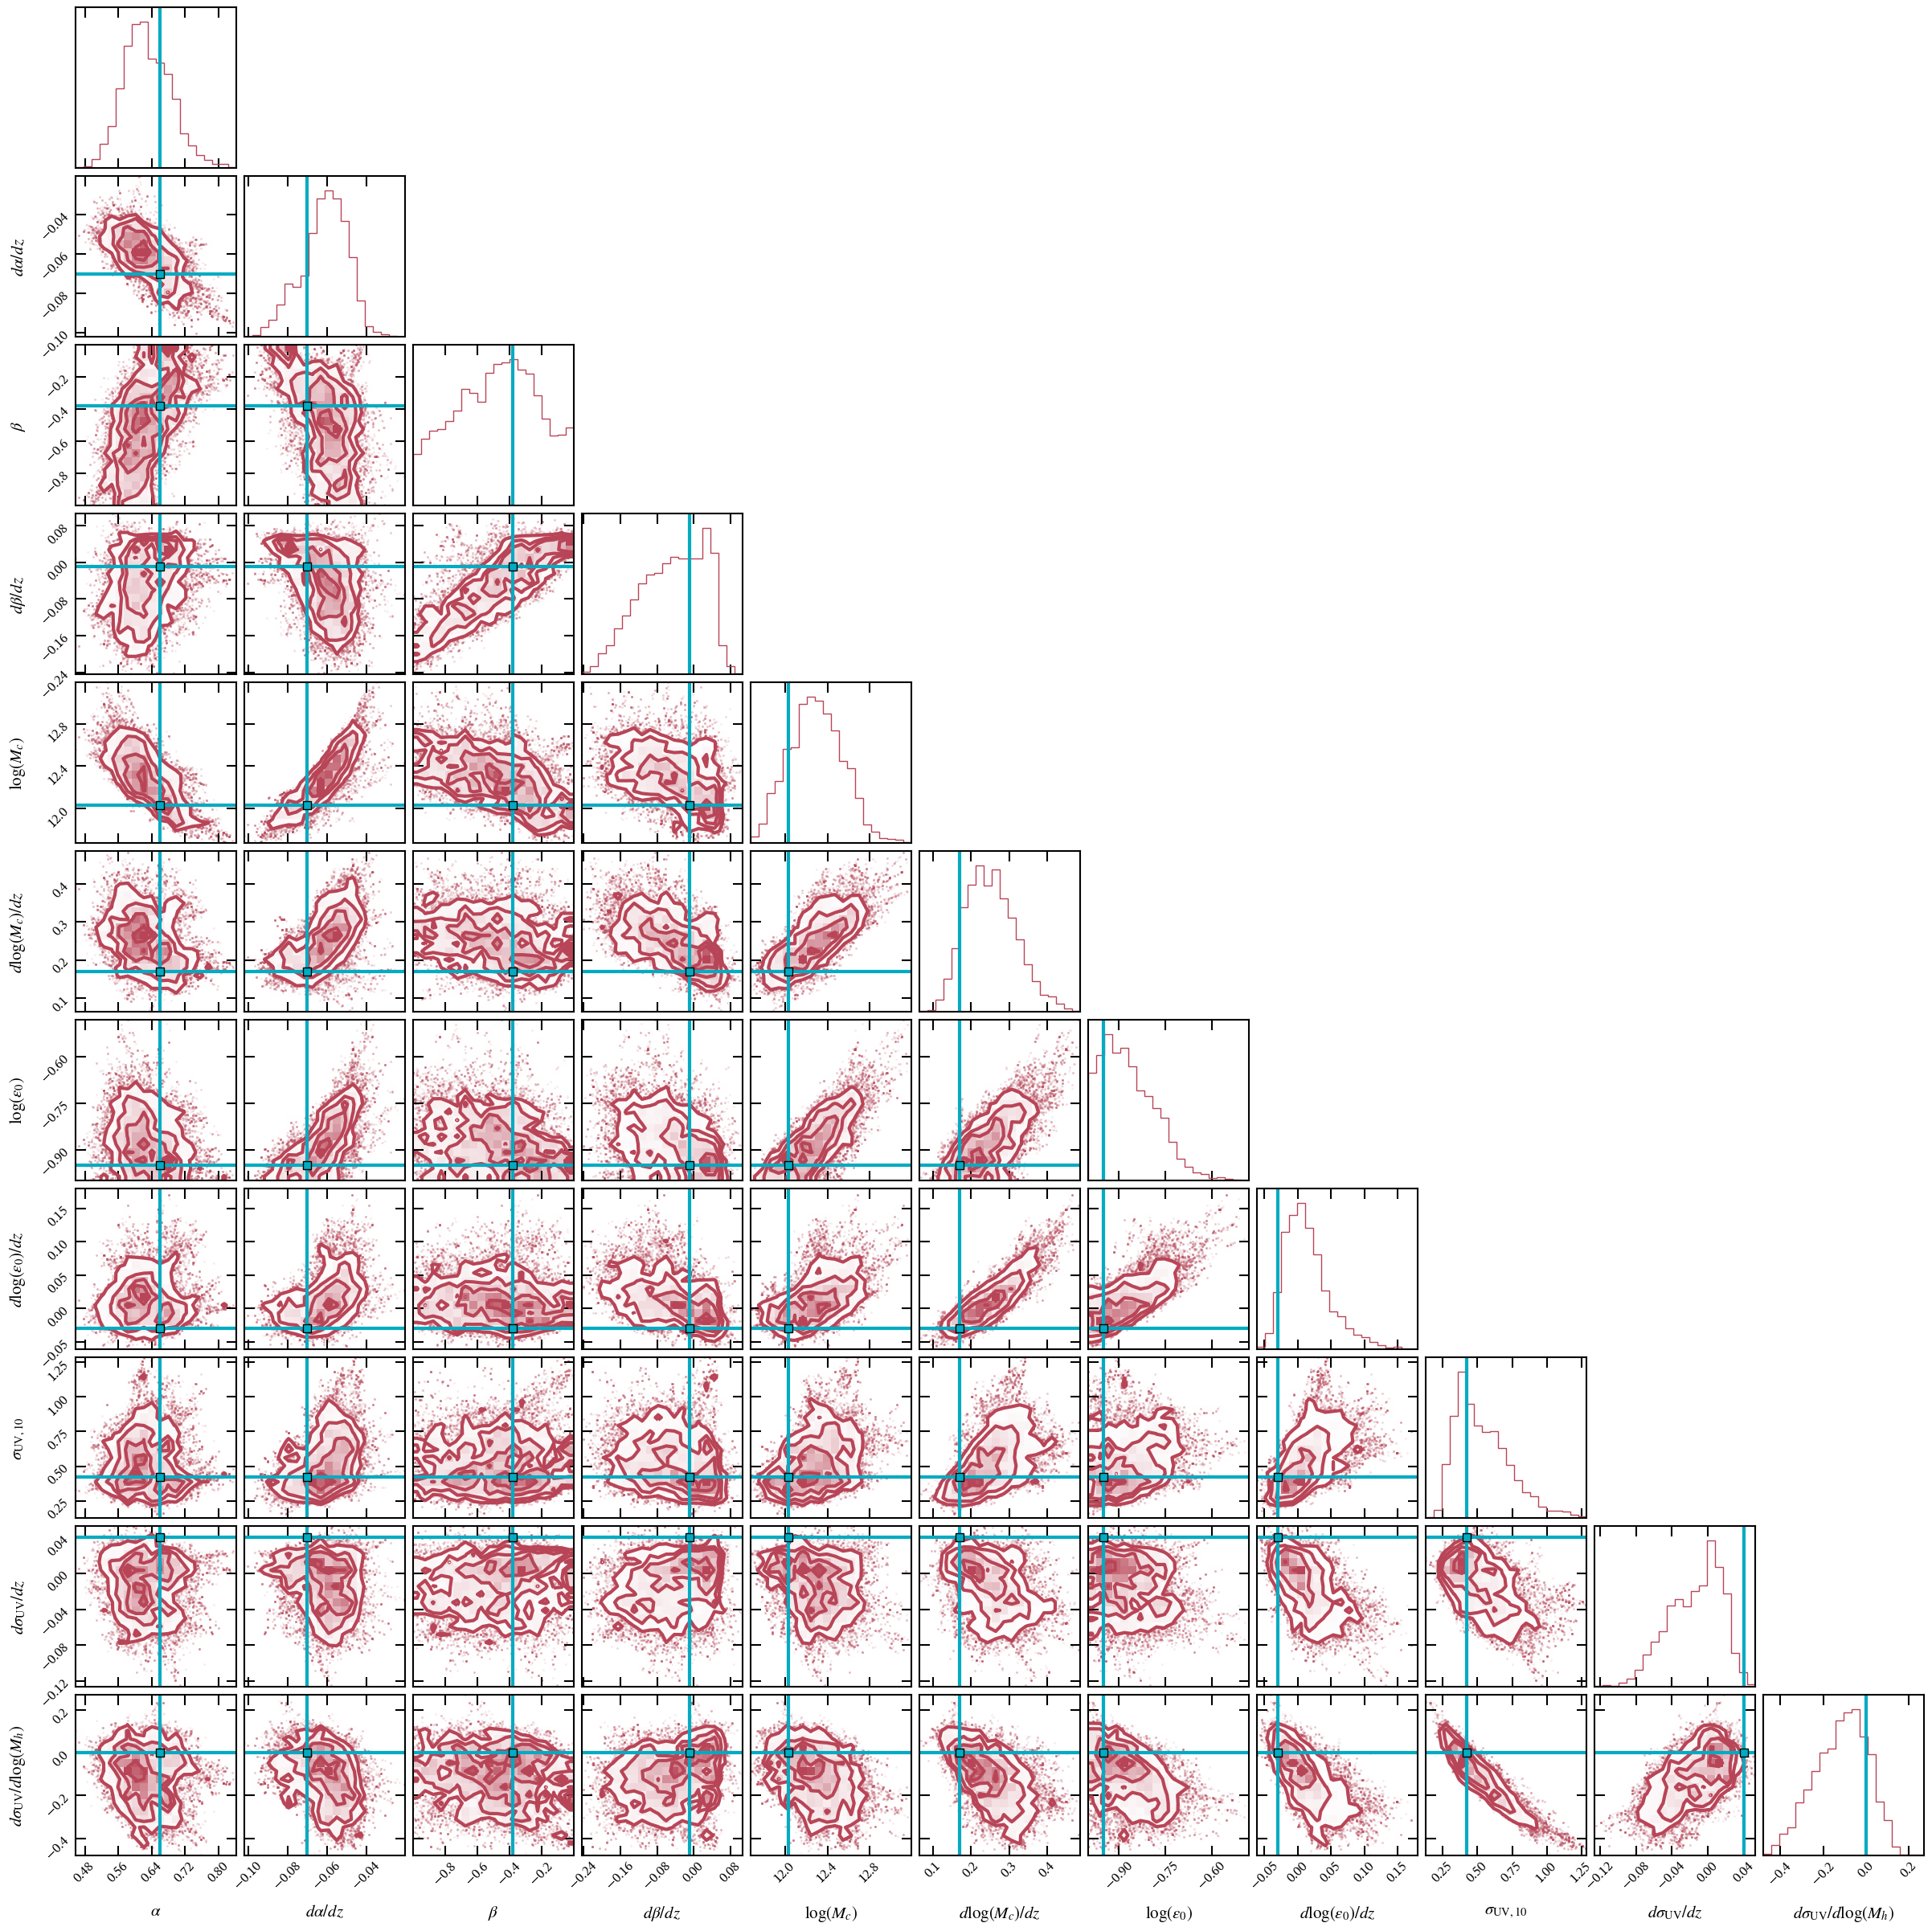

In [309]:
corner_true = Plotting.plot_corner(samples, mock_UVLF, true_vals = true_params)

In [310]:
#corner_true.savefig('/Users/eb35267/Desktop/code/figures/sigma_function/corner_known_truth.png', bbox_inches='tight')

In [317]:
importlib.reload(eplots)
Plotting = eplots.Plotting()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


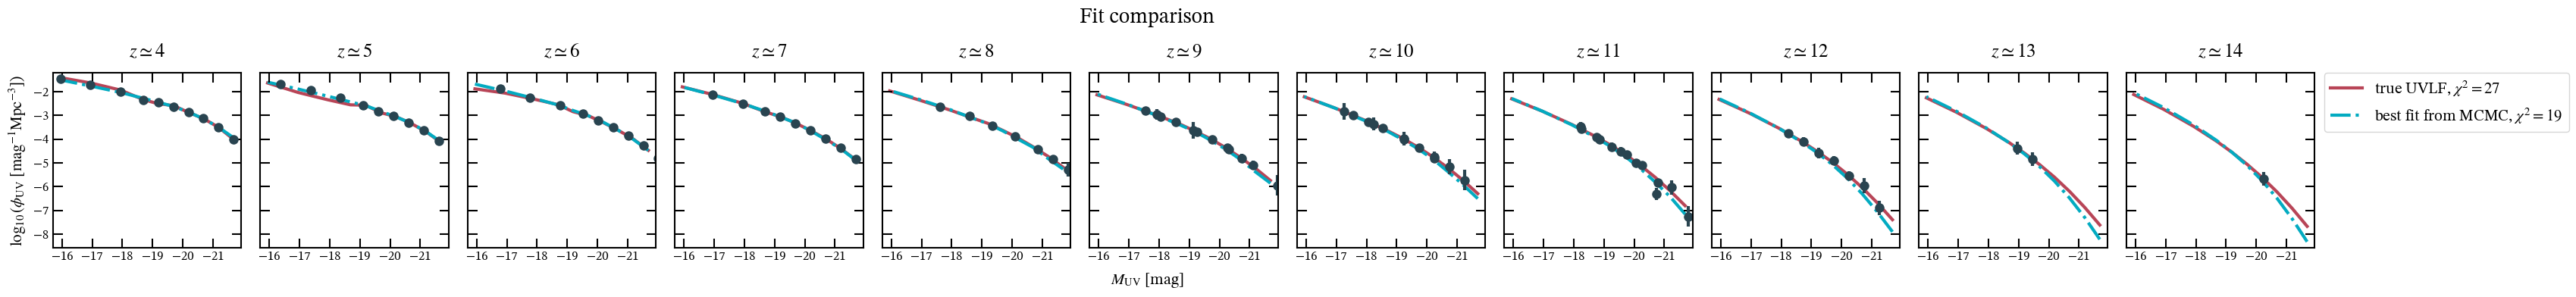

In [324]:
comparison = Plotting.compare_fits(mock_files, data_labels = [''], best_fits = [true_params, best_fit], 
                                   fit_labels = ['true UVLF', 'best fit from MCMC'])

In [280]:
#comparison.savefig('/Users/eb35267/Desktop/code/figures/sig_functional_form/wonky_fit.png', bbox_inches='tight')

In [336]:
percent_diff = np.round(np.abs((np.array(true_params) - np.array(best_fit))/true_params)*100, 1)

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_32938/394403596.py:1: RuntimeWarning: divide by zero encountered in divide
  percent_diff = np.round(np.abs((np.array(true_params) - np.array(best_fit))/true_params)*100, 1)


In [337]:
eMCMC.make_table([true_params, best_fit, percent_diff], labels, 
                 ['true parameters', 'best fit from MCMC', '% difference'])

,true parameters,best fit from MCMC,% difference
$\alpha$,0.66,0.62,6.1
$d\alpha/dz$,-0.07,-0.06,14.3
$\beta$,-0.38,-0.49,28.9
$d\beta/dz$,-0.01,-0.07,600.0
$\log(M_c)$,12.03,12.36,2.7
$d\log(M_c)/dz$,0.17,0.27,58.8
$\log(\epsilon_0)$,-0.95,-0.83,12.6
$d\log(\epsilon_0)/dz$,-0.03,0.01,133.3
"$\sigma_{\rm{UV}, 10}$",0.42,0.50,19.0
$d\sigma_{\rm{UV}}/dz$,0.04,0.00,100.0


# Testing chi squared

In [254]:
all_uvlfs = []
all_data = []
yas = []
all_loglike = []
chi2 = 0

for i, dataarrayz in enumerate(mock_UVLF.data):
    zdat, zerr, xdat, ydat, yerr_upper, yerr_lower, xerr = eMCMC.decompose_data(dataarrayz)

    all_data.append(ydat)
    
    # Plot best fit:
    uvlftheory = mock_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit)
    all_uvlfs.append(uvlftheory)
    yerr_asymmetrical = np.array([yerr_upper[i] if uvlftheory[i] > ydat[i] else yerr_lower[i] for i in range(len(ydat))])
    yasb.append(yerr_asymmetrical)

    # this formula is just proportional to the natural log of a Gaussian
    log_like_piece = [(yd - ut)**2/(2*ya**2) for yd, ut, ya in zip(ydat, uvlftheory, yerr_asymmetrical)]
    all_loglike.append(log_like_piece)

    chi2 += 2*np.sum(log_like_piece)

In [269]:
all_uvlfs[7]

array([-2.67276360e-09, -5.75645040e-08,  5.13497488e-08,  6.35109314e-07,
        6.05243609e-07,  4.85298022e-06,  5.11620117e-06,  1.30868364e-05,
        2.42309217e-05,  3.32289838e-05,  8.60229071e-05,  1.03567854e-04,
        2.01859477e-04,  2.09547271e-04])

In [270]:
all_data[7]

array([1.0404e-08, 9.3068e-08, 4.4406e-07, 8.0635e-07, 7.8892e-08,
       2.0045e-06, 9.9753e-06, 2.0945e-05, 2.8151e-05, 7.9345e-05,
       8.2180e-05, 1.2580e-04, 2.7312e-04, 2.0507e-04])

In [271]:
yas[7]

array([1.0404e-08, 9.2346e-08, 3.1719e-07, 2.7521e-07, 6.1987e-08,
       8.4401e-07, 3.3636e-06, 6.7024e-06, 1.1979e-05, 3.4713e-05,
       3.2151e-05, 5.1612e-05, 1.2399e-04, 9.3140e-05])

[0.7898959060632698,
 1.3303662477189635,
 0.7664353137329706,
 0.19357777900011036,
 36.05127903390054,
 5.695098459247277,
 1.0434527322212428,
 0.6873080808723193,
 0.05354493005776847,
 0.8824483060314444,
 0.0071433314747145855,
 0.09277509439122805,
 0.16515612734930707,
 0.0011553784590961683]

In [278]:
(6.05243609e-07-7.8892e-08)**2/(2*6.1987e-08**2)

36.05127906285838

In [277]:
my_UVLF.data[7][2]

array([-21.25, -20.75, -20.25, -19.75, -19.25, -18.75, -18.25, -22.57,
       -21.8 , -20.8 , -20.05, -19.55, -18.85, -18.23])